In [20]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations
import os


In [53]:
df = pd.read_csv('full_image_data_feb_25.csv')
books = pd.read_csv('full_book_data_feb_25.csv')
ucks = pd.read_excel('all_elements_all_ck_ucks.xlsx')

In [54]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [55]:
#get all cluster names that have visual tagging (take the cluater names values from all VT files in the folder)

folder_path = '/Users/nogashlomi/projects/Image_data/visual_tags'  # Change this to your folder path

unique_clusters_with_visual_tags = set()

for filename in os.listdir(folder_path):
    if filename.endswith('.csv') or filename.endswith('.xlsx'):
        file_path = os.path.join(folder_path, filename)
        
        try:
            if filename.endswith('.csv'):
                file_df = pd.read_csv(file_path)
            else:  # Excel file
                file_df = pd.read_excel(file_path)
            
            if 'cluster_name' in file_df.columns:
                unique_clusters_with_visual_tags.update(file_df['cluster_name'].dropna().unique())
            else:
                print(f"'cluster_name' column not found in {filename}")
        
        except Exception as e:
            print(f"Error reading {filename}: {e}")

# Now you can print or use the set as needed
# print("Unique cluster_name values across all files:")
# print(unique_clusters_with_visual_tags)


In [66]:
#add to ucks df a column with visual tagging yes or no values

# Clean label column in ucks
ucks['label'] = ucks['label'].astype(str).str.strip()

# Add the visual_tag column: 'yes' if label in unique_clusters_with_visual_tags, else 'no'
ucks['visual_tag'] = ucks['label'].apply(lambda x: 'yes' if x in unique_clusters_with_visual_tags else 'no')

# # Check the result
# print(ucks[['label', 'visual_tag']].head(10))



In [67]:
ucks

,images,label,uck,level,visual_tag
0,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
1,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
2,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
3,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
4,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
...,...,...,...,...,...
216961,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01573,MVK_Diagrams,0,no
216962,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01604,MVK_Diagrams,0,yes
216963,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01604,MVK_Diagrams,0,yes
216964,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01607,MTK_Mercury Orbit_Group_01,0,no


In [79]:
merged_df = df.merge(
    ucks,
    how='left',
    left_on='cluster_name',
    right_on='label',
    suffixes=('', '_ucks')
).drop(columns=['label'])
merged_df

,images,cluster_name,cks,book,bid,part_or_adaption,part_or_adaption_label,type_label,custom_identifier,place,...,year_interval,place_category,latitude,longitude,printer,publisher,images_ucks,uck,level,visual_tag
0,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
1,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
2,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
3,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
4,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17108805,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,1590-1609,Medium Center,51.489334,-0.144055,"Judson, Thomas","Jaggard, William",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Definition of Sphere,1,yes
17108806,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,1590-1609,Medium Center,51.489334,-0.144055,"Judson, Thomas","Jaggard, William",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,CK_Definition of Sphere by Euclid,0,yes
17108807,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,1590-1609,Medium Center,51.489334,-0.144055,"Judson, Thomas","Jaggard, William",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,MVK_Pictorial_Illustrations,0,yes
17108808,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,15

In [68]:
import os
import pandas as pd

folder_path = '/Users/nogashlomi/projects/Image_data/visual_tags'

unique_clusters_with_visual_tags = set()

for filename in os.listdir(folder_path):
    if filename.endswith('.csv') or filename.endswith('.xlsx'):
        file_path = os.path.join(folder_path, filename)
        
        try:
            if filename.endswith('.csv'):
                file_df = pd.read_csv(file_path)
            else:
                file_df = pd.read_excel(file_path)
            
            if 'cluster_name' in file_df.columns:
                unique_clusters_with_visual_tags.update(file_df['cluster_name'].dropna().unique())
            else:
                print(f"'cluster_name' column not found in {filename}")
        
        except Exception as e:
            print(f"Error reading {filename}: {e}")

# Now your original df is still intact, so you can safely run:
df_unique_clusters = set(df['cluster_name'].dropna().unique())

shared_clusters = df_unique_clusters.intersection(unique_clusters_with_visual_tags)

print(f"Number of unique cluster_names in df that also appear in folder files: {len(shared_clusters)}")

cks_groups = df.groupby('cks')['cluster_name'].apply(lambda x: set(x.dropna().unique()))

cks_only_in_folder = cks_groups[cks_groups.apply(lambda clusters: clusters.issubset(unique_clusters_with_visual_tags))]

print("cks values exclusively associated with cluster_names in folder files:")
print(cks_only_in_folder.index.tolist())


Number of unique cluster_names in df that also appear in folder files: 1573
cks values exclusively associated with cluster_names in folder files:
['CK_Additions on Definitions of the Sphere', 'CK_Apparent Size of Stars', 'CK_Ascensions', 'CK_Ascensions in the Right and Oblique Sphere', 'CK_Assumed Parallellity of the Sun Rays', 'CK_Central Intersection of Eclipses', 'CK_Centrality of Earth', 'CK_Chronical Rising and Setting', 'CK_Circle and Diameter Rule', 'CK_Circles of Equant Deferent Epicycle', 'CK_Circles of Natural Days', 'CK_Colures', 'CK_Complete Motion of the Eighth Sphere', 'CK_Complete Motion of the Eighth Sphere (Thebit)', 'CK_Computus Ecclesiasticus Pentacost', 'CK_Conical Shape of Planetary Shadow', 'CK_Correlation Between Distances on Earth and Locations of Stars', 'CK_Cosmic Rising and Setting', 'CK_Daily Rotation of the Firmament', 'CK_Definition of Sphere by Euclid', 'CK_Definition of Sphere by Theodosius', 'CK_Distances between Small Circles', 'CK_Ecumene Conception',

In [69]:
# Get all unique cks values from df
unique_cks = set(df['cks'].dropna())

# Group by cks and get their associated cluster_name sets
cks_to_clusters = df.groupby('cks')['cluster_name'].apply(lambda x: set(x.dropna().unique()))

# Select cks where all associated cluster_names are fully visual tagged
visual_tagged_cks = cks_to_clusters[cks_to_clusters.apply(lambda clusters: clusters.issubset(unique_clusters_with_visual_tags))].index

# Show results
print(f"Total unique cks values in df: {len(unique_cks)}")
print(f"Number of cks values with full visual tag coverage: {len(visual_tagged_cks)}")
print(f"Percentage fully tagged: {len(visual_tagged_cks) / len(unique_cks) * 100:.2f}%")


Total unique cks values in df: 168
Number of cks values with full visual tag coverage: 68
Percentage fully tagged: 40.48%


In [70]:
# Unique images total
total_unique_images = df['images'].nunique()

# Unique images with visually tagged cluster_name
images_with_tagged_clusters = df[df['cluster_name'].isin(unique_clusters_with_visual_tags)]
unique_tagged_images = images_with_tagged_clusters['images'].nunique()

# Unique images without visually tagged cluster_name
unique_untagged_images = total_unique_images - unique_tagged_images

print(f"Total unique images: {total_unique_images}")
print(f"Unique images with visually tagged cluster_name: {unique_tagged_images}")
print(f"Unique images without visually tagged cluster_name: {unique_untagged_images}")
print(f"Percentage tagged: {unique_tagged_images / total_unique_images * 100:.2f}%")
print(f"Percentage untagged: {unique_untagged_images / total_unique_images * 100:.2f}%")


Total unique images: 20540
Unique images with visually tagged cluster_name: 12837
Unique images without visually tagged cluster_name: 7703
Percentage tagged: 62.50%
Percentage untagged: 37.50%


In [75]:
# UCK values to check
target_ucks = ['INSTRUMENTS', 'PRACTICAL ACTIVITIES', 'DISCIPLINES']

# Make sure columns are cleaned
ucks['uck'] = ucks['uck'].astype(str).str.strip()
ucks['visual_tag'] = ucks['visual_tag'].astype(str).str.strip()

# Filter the DataFrame for the desired UCK values
filtered = ucks[ucks['uck'].isin(target_ucks)]

# Group by 'uck' and count unique images (total)
total_counts = filtered.groupby('uck')['images'].nunique()

# Group by 'uck' and count unique images that are visually tagged
tagged_counts = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby('uck')['images']
    .nunique()
)

# Combine into one DataFrame
result = pd.DataFrame({
    'total_images': total_counts,
    'tagged_images': tagged_counts
}).fillna(0).astype(int)

# Add percentage column
result['percentage_tagged'] = (result['tagged_images'] / result['total_images'] * 100).round(2)

# Show the result
print(result)


                      total_images  tagged_images  percentage_tagged
uck                                                                 
DISCIPLINES                  19872          12909              64.96
INSTRUMENTS                   1276            285              22.34
PRACTICAL ACTIVITIES          2390            613              25.65


In [77]:
# Target UCKs (case-sensitive, exact match)
target_ucks = [
    'Astronomy',
    'Geometry',
    'Cosmography and Geography',
    'Optics',
    'Arithmetic',
    'Mechanics',
    'Meteorology',
    'Mucis'  # Or replace with 'Music' if that's the correct value
]

# Clean relevant columns
ucks['uck'] = ucks['uck'].astype(str).str.strip()
ucks['visual_tag'] = ucks['visual_tag'].astype(str).str.strip()

# Total number of unique images in the entire dataset
total_images_in_corpus = ucks['images'].nunique()

# Filter only rows matching the target UCKs
filtered = ucks[ucks['uck'].isin(target_ucks)]

# Total unique image count per UCK
total_counts = filtered.groupby('uck')['images'].nunique()

# Tagged image count per UCK
tagged_counts = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby('uck')['images']
    .nunique()
)

# Combine into a result DataFrame
result = pd.DataFrame({
    'total_images': total_counts,
    'tagged_images': tagged_counts
}).fillna(0).astype(int)

# Add percentage of tagged images (per UCK)
result['percentage_tagged'] = (result['tagged_images'] / result['total_images'] * 100).round(2)

# Add percentage of corpus images represented by each UCK
result['percentage_of_corpus'] = (result['total_images'] / total_images_in_corpus * 100).round(2)

# Display the result
print(result)


                           total_images  tagged_images  percentage_tagged  \
uck                                                                         
Arithmetic                           56              0               0.00   
Astronomy                         15128          12328              81.49   
Cosmography and Geography          1511           1275              84.38   
Geometry                           5823           2161              37.11   
Mechanics                            26              0               0.00   
Meteorology                         332            273              82.23   
Optics                              868            380              43.78   

                           percentage_of_corpus  
uck                                              
Arithmetic                                 0.27  
Astronomy                                 73.08  
Cosmography and Geography                  7.30  
Geometry                                  28.13  
Mechan

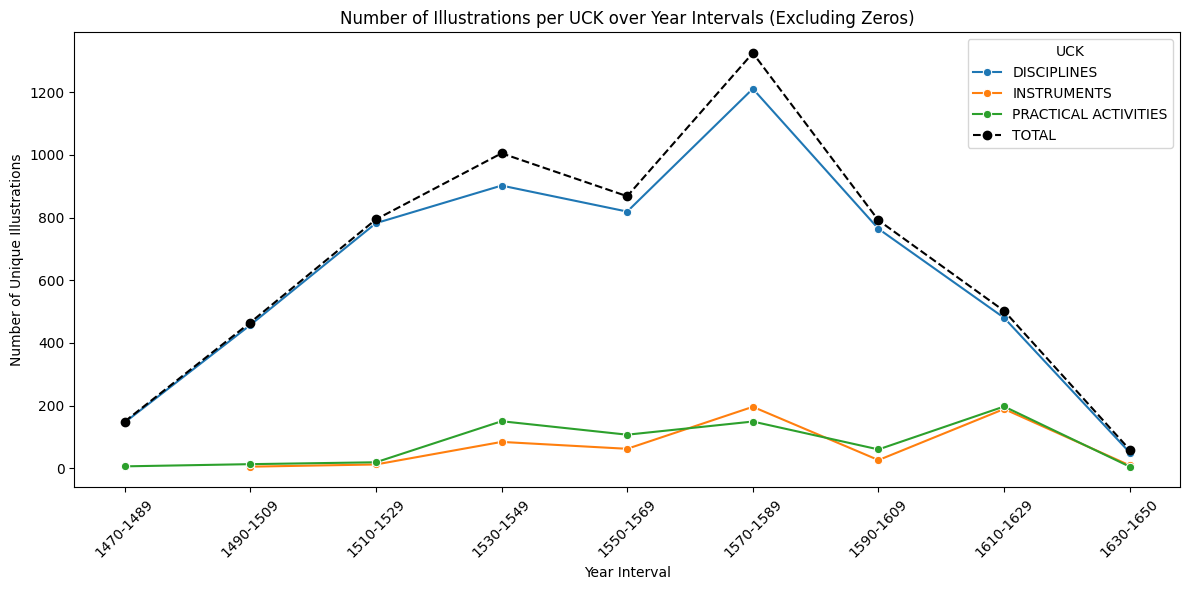

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the UCKs you're interested in
target_ucks = ['INSTRUMENTS', 'PRACTICAL ACTIVITIES', 'DISCIPLINES']

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()

# Filter merged_df to only target UCKs
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# --- Group by uck and year_interval ---
grouped = (
    filtered.groupby(['uck', 'year_interval'])['cluster_name']
    .nunique()
    .reset_index()
    .rename(columns={'cluster_name': 'num_illustrations'})
)

# --- Create TOTAL line ---
total = (
    merged_df.groupby('year_interval')['cluster_name']
    .nunique()
    .reset_index()
    .rename(columns={'cluster_name': 'num_illustrations'})
)
total['uck'] = 'TOTAL'

# Combine all data
combined = pd.concat([grouped, total], ignore_index=True)

# --- Remove zero values (bro = 0) ---
combined = combined[combined['num_illustrations'] > 0]

# --- Plot ---
plt.figure(figsize=(12, 6))

# Plot all UCKs except TOTAL
for uck_value in combined['uck'].unique():
    uck_data = combined[combined['uck'] == uck_value]
    
    if uck_value == 'TOTAL':
        # Plot TOTAL line in black, dashed
        plt.plot(
            uck_data['year_interval'],
            uck_data['num_illustrations'],
            label='TOTAL',
            color='black',
            linestyle='--',
            marker='o'
        )
    else:
        # Plot regular UCK lines
        sns.lineplot(
            data=uck_data,
            x='year_interval',
            y='num_illustrations',
            label=uck_value,
            marker='o'
        )

plt.title('Number of Illustrations per UCK over Year Intervals (Excluding Zeros)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Illustrations')
plt.xticks(rotation=45)
plt.legend(title='UCK')
plt.tight_layout()
plt.show()


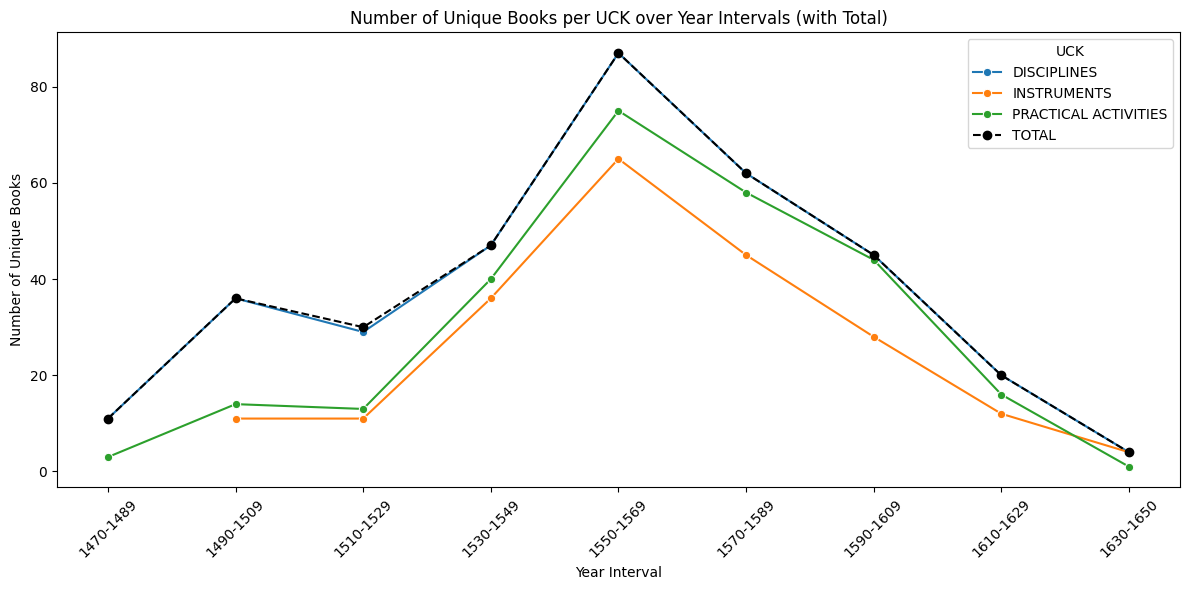

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define UCKs of interest
target_ucks = ['INSTRUMENTS', 'PRACTICAL ACTIVITIES', 'DISCIPLINES']

# Clean columns (in case)
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()

# ---- Filter for the selected UCKs ----
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# ---- Count unique books per UCK and year_interval ----
uck_counts = (
    filtered.groupby(['uck', 'year_interval'])['book']
    .nunique()
    .reset_index()
    .rename(columns={'book': 'num_unique_books'})
)

# ---- Compute TOTAL books per year_interval (regardless of UCK) ----
total_counts = (
    merged_df.groupby('year_interval')['book']
    .nunique()
    .reset_index()
    .rename(columns={'book': 'num_unique_books'})
)
total_counts['uck'] = 'TOTAL'  # Label for plotting

# ---- Combine both ----
combined = pd.concat([uck_counts, total_counts], ignore_index=True)

# ---- Remove zero values if any ----
combined = combined[combined['num_unique_books'] > 0]

# ---- Plot ----
plt.figure(figsize=(12, 6))

# Plot each UCK separately
for uck_value in combined['uck'].unique():
    data = combined[combined['uck'] == uck_value]
    
    if uck_value == 'TOTAL':
        plt.plot(
            data['year_interval'],
            data['num_unique_books'],
            label='TOTAL',
            color='black',
            linestyle='--',
            marker='o'
        )
    else:
        sns.lineplot(
            data=data,
            x='year_interval',
            y='num_unique_books',
            label=uck_value,
            marker='o'
        )

# ---- Final touches ----
plt.title('Number of Unique Books per UCK over Year Intervals (with Total)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='UCK')
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_uck_lines.png', dpi=300)

plt.show()


In [90]:
# Clean the 'uck' column
ucks['uck'] = ucks['uck'].astype(str).str.strip()

# Filter out values starting with CK, MTK, SK, or VK
excluded_prefixes = ('CK', 'MTK', 'SK', 'VK', 'MVK', 'VK', 'Per', 'Ger')
non_prefixed_ucks = ucks[~ucks['uck'].str.startswith(excluded_prefixes)]['uck'].unique()

# Sort and print
non_prefixed_ucks = sorted(non_prefixed_ucks)
for val in non_prefixed_ucks:
    print(val)


Arithmetic
Ascensions
Astrology
Astronomy
Astronomy of the Eighth Sphere
Calendric
Cartography
Celestial circles
Constellations
Cosmography and Geography
DISCIPLINES
Definition of Sphere
Didactic Instruments
Dimensions of the Earth
Distribution of Land and Water
Division of the Cosmos by the Signs
Divisions of the Eighth Sphere
Fixed great Circles
Four small circles
General Geometry and Principles of Planetary Movements
Geocentric Cosmology
Geometric Subjects
Geometry
Great Circles at Different Locations (meridian and horizon)
Heliocentric Astronomy
INSTRUMENTS
Instrumental Geometric Demonstrations
Jupiter
Mars
Mechanics
Medicine
Mercury
Meteorology
Metrics of the surface of the Earth
Moon
Movement of the Eighth Sphere
Movement of the Ninth Sphere
Music
Navigation
Observer Perspective
Optics
PRACTICAL ACTIVITIES
Planetary Astronomy
Position of the Earth
Relations Between Celestial Bodies
Relations Between Earth and Cosmos
Relations between the Elements of Water and Earth
Rising and Set

/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_84140/788353898.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


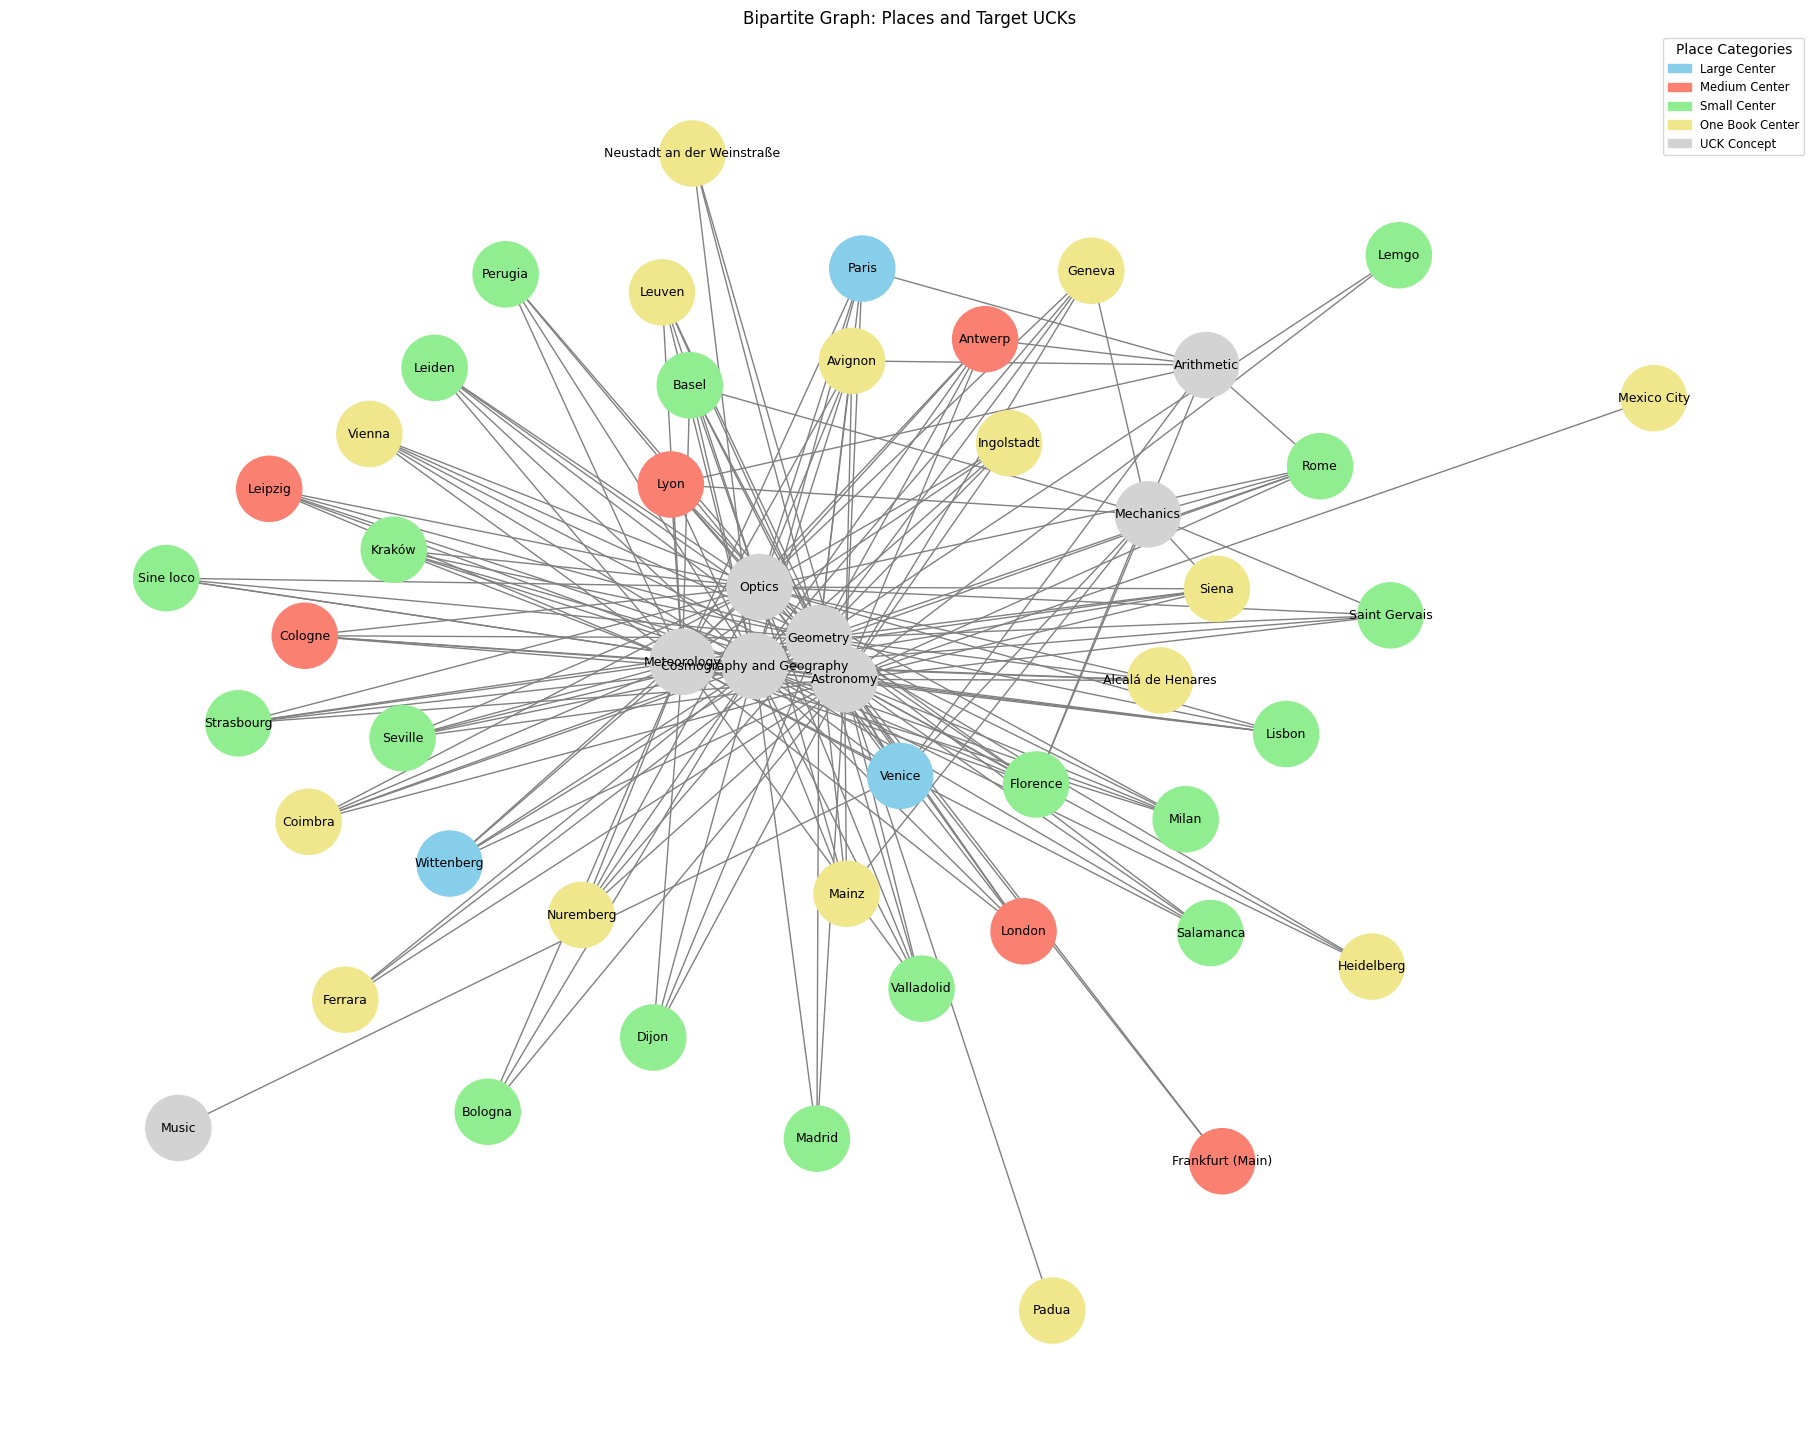

In [108]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

# === Replace this with your actual merged_df ===
# merged_df = pd.read_csv("your_merged_data.csv")

# === Step 1: Define target UCK values ===
target_uck_values = [
   'Arithmetic', 
    # 'Astrology', 
    'Astronomy', 
    # 'Astronomy of the Eighth Sphere',
    # 'Calendric', 
    # 'Cartography', 
    'Cosmography and Geography', 
    # 'DISCIPLINES',
    'Geometry', 
    # 'INSTRUMENTS', 
    'Mechanics', 
    # 'Medicine', 
    'Meteorology',
    'Music', 
    # 'Navigation', 
    'Optics', 
    # 'PRACTICAL ACTIVITIES', 
    # 'Planetary Astronomy'
]

# === Step 2: Filter data ===
filtered_df = merged_df[
    merged_df['uck'].isin(target_uck_values) &
    merged_df['place'].notna()
]

# === Step 3: Create edges (place ↔ uck) ===
edges = list(zip(filtered_df['place'], filtered_df['uck']))
places = filtered_df['place'].unique().tolist()
ucks = filtered_df['uck'].unique().tolist()

# === Step 4: Map place categories to colors ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
existing_categories = filtered_df['place_category'].dropna().unique().tolist()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in places:
    cat_series = filtered_df[filtered_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Step 5: Build and draw the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(ucks, bipartite=1)
G.add_edges_from(edges)

node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, seed=42, k=1)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2200,
    font_size=9
)

# === Step 6: Add legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='UCK Concept'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and Target UCKs")
plt.tight_layout()
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_84140/1071318851.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered.groupby(['uck', 'year_interval'])['cluster_name']
/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_84140/1071318851.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby('year_interval')['cluster_name']


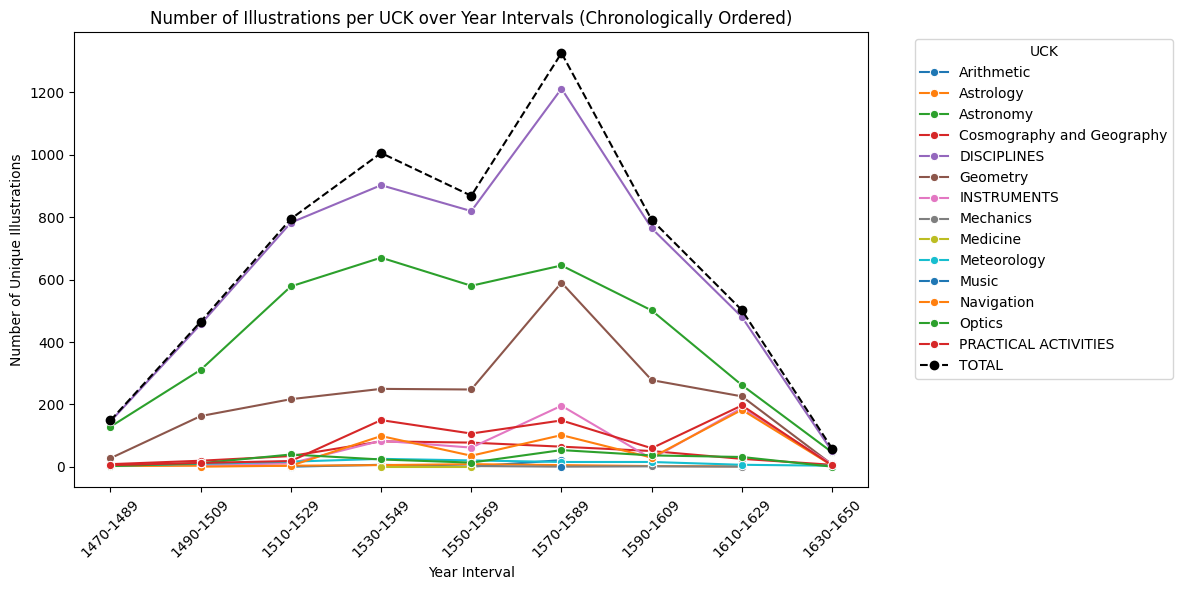

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the UCKs you're interested in
target_ucks = [
    'Arithmetic', 
    'Astrology', 
    'Astronomy', 
    # 'Astronomy of the Eighth Sphere',
    # 'Calendric', 
    # 'Cartography', 
    'Cosmography and Geography', 
    'DISCIPLINES',
    'Geometry', 
    'INSTRUMENTS', 
    'Mechanics', 
    'Medicine', 
    'Meteorology',
    'Music', 
    'Navigation', 
    'Optics', 
    'PRACTICAL ACTIVITIES', 
    # 'Planetary Astronomy'
]

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()

# Determine the correct chronological order of year intervals
# Example assumes format like '1450-1475', '1475-1500', etc.
year_intervals_sorted = sorted(merged_df['year_interval'].dropna().unique(), key=lambda x: int(x.split('-')[0]))
merged_df['year_interval'] = pd.Categorical(merged_df['year_interval'], categories=year_intervals_sorted, ordered=True)

# Filter merged_df to only target UCKs
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# --- Group by uck and year_interval ---
grouped = (
    filtered.groupby(['uck', 'year_interval'])['cluster_name']
    .nunique()
    .reset_index()
    .rename(columns={'cluster_name': 'num_illustrations'})
)

# --- Create TOTAL line ---
total = (
    merged_df.groupby('year_interval')['cluster_name']
    .nunique()
    .reset_index()
    .rename(columns={'cluster_name': 'num_illustrations'})
)
total['uck'] = 'TOTAL'

# Combine all data
combined = pd.concat([grouped, total], ignore_index=True)

# --- Remove zero values ---
combined = combined[combined['num_illustrations'] > 0]

# Ensure correct order in final DataFrame
combined['year_interval'] = pd.Categorical(combined['year_interval'], categories=year_intervals_sorted, ordered=True)

# --- Plot ---
plt.figure(figsize=(12, 6))

# Plot all UCKs except TOTAL
for uck_value in combined['uck'].unique():
    uck_data = combined[combined['uck'] == uck_value].sort_values('year_interval')
    
    if uck_value == 'TOTAL':
        plt.plot(
            uck_data['year_interval'],
            uck_data['num_illustrations'],
            label='TOTAL',
            color='black',
            linestyle='--',
            marker='o'
        )
    else:
        sns.lineplot(
            data=uck_data,
            x='year_interval',
            y='num_illustrations',
            label=uck_value,
            marker='o'
        )

plt.title('Number of Illustrations per UCK over Year Intervals (Chronologically Ordered)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Illustrations')
plt.xticks(rotation=45)
plt.legend(title='UCK', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


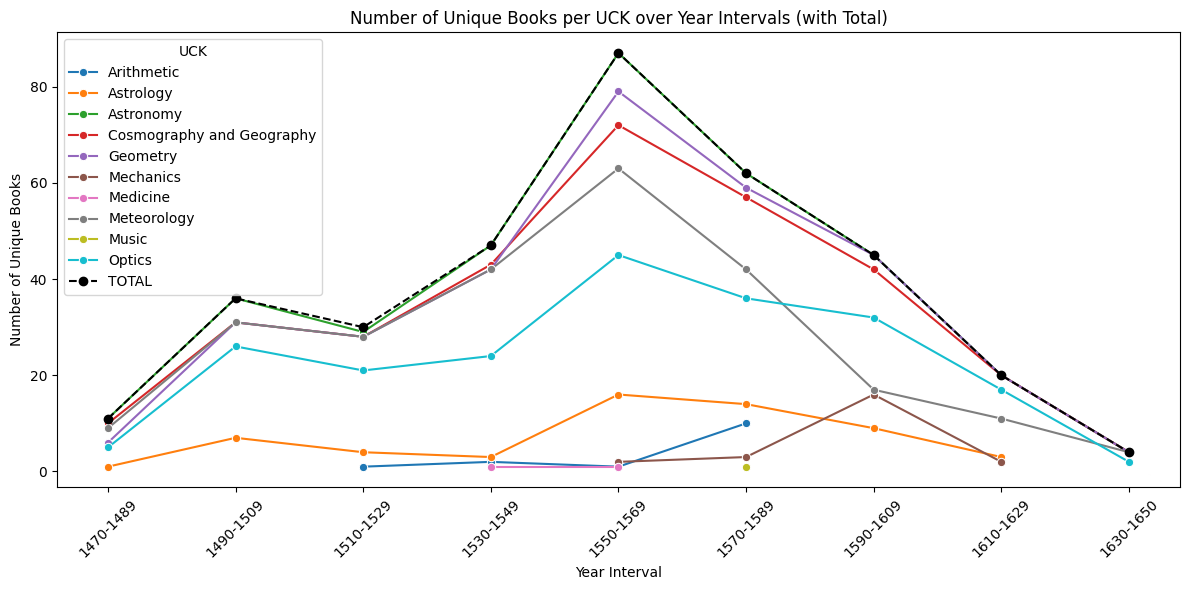

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define UCKs of interest (updated with commented out options for flexibility)
target_ucks = [
    'Arithmetic', 
    'Astrology', 
    'Astronomy', 
    'Cosmography and Geography', 
    # 'DISCIPLINES',
    'Geometry', 
    # 'INSTRUMENTS', 
    'Mechanics', 
    'Medicine', 
    'Meteorology', 
    'Music', 
    # 'Navigation', 
    'Optics', 
    # 'PRACTICAL ACTIVITIES'
]

# Clean columns (in case)
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()

# Define a proper order for year intervals to avoid messy plots
year_order = sorted(merged_df['year_interval'].unique(), key=lambda x: int(x.split('-')[0]) if '-' in x else int(x))

# ---- Filter for the selected UCKs ----
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# ---- Count unique books per UCK and year_interval ----
uck_counts = (
    filtered.groupby(['uck', 'year_interval'], observed=False)['book']
    .nunique()
    .reset_index()
    .rename(columns={'book': 'num_unique_books'})
)

# ---- Compute TOTAL books per year_interval (regardless of UCK) ----
total_counts = (
    merged_df.groupby('year_interval', observed=False)['book']
    .nunique()
    .reset_index()
    .rename(columns={'book': 'num_unique_books'})
)
total_counts['uck'] = 'TOTAL'  # Label for plotting

# ---- Combine both ----
combined = pd.concat([uck_counts, total_counts], ignore_index=True)

# ---- Remove zero values if any ----
combined = combined[combined['num_unique_books'] > 0]

# ---- Set categorical order for year_interval ----
combined['year_interval'] = pd.Categorical(combined['year_interval'], categories=year_order, ordered=True)

# ---- Plot ----
plt.figure(figsize=(12, 6))

# Plot each UCK separately
for uck_value in combined['uck'].unique():
    data = combined[combined['uck'] == uck_value]
    
    if uck_value == 'TOTAL':
        plt.plot(
            data['year_interval'],
            data['num_unique_books'],
            label='TOTAL',
            color='black',
            linestyle='--',
            marker='o'
        )
    else:
        sns.lineplot(
            data=data,
            x='year_interval',
            y='num_unique_books',
            label=uck_value,
            marker='o'
        )

# ---- Final touches ----
plt.title('Number of Unique Books per UCK over Year Intervals (with Total)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='UCK')
plt.tight_layout()
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_84140/2331185101.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


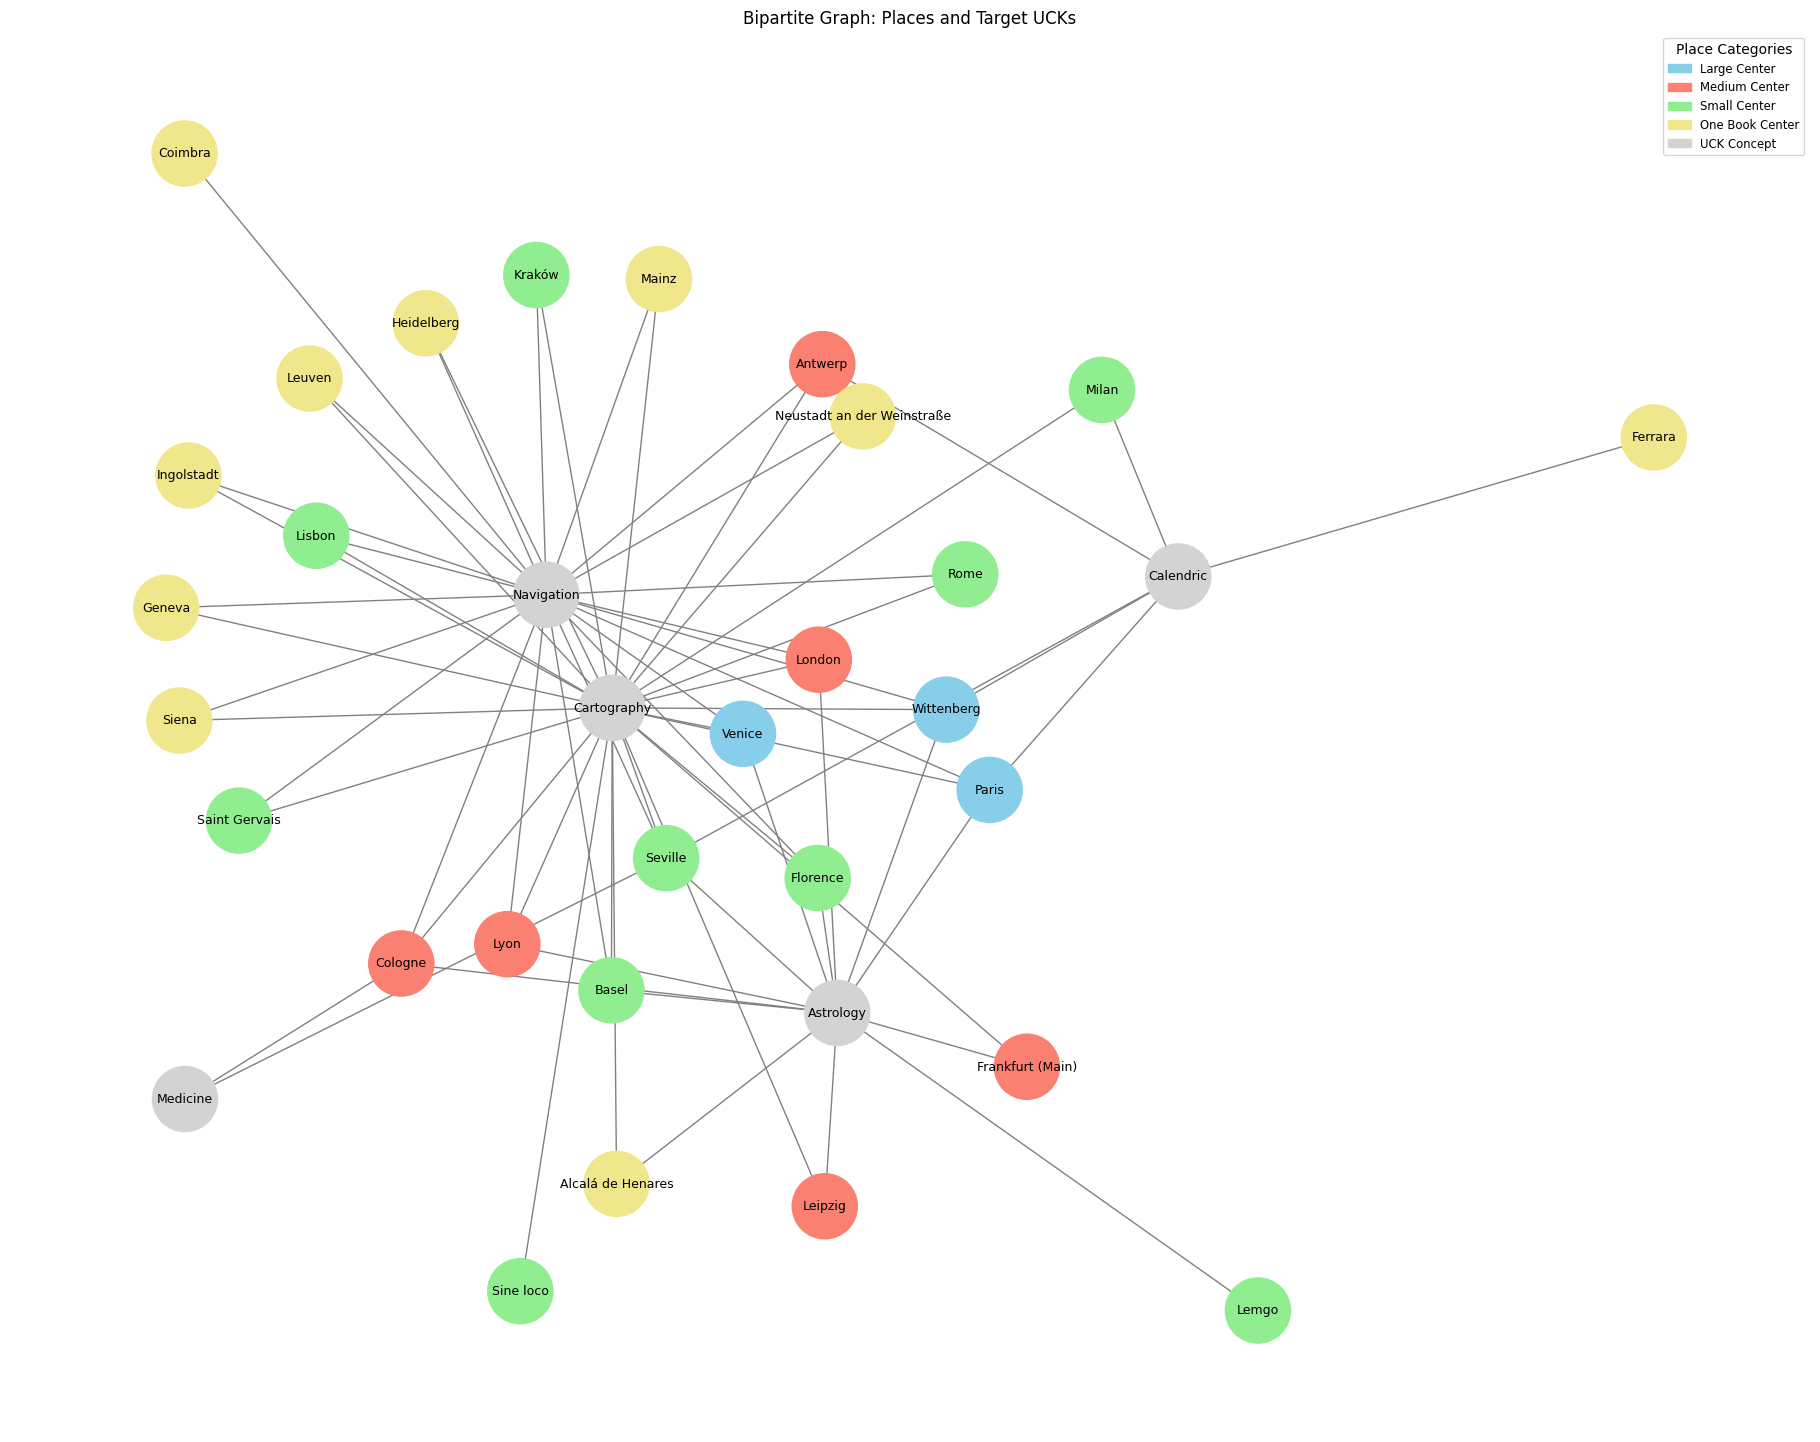

In [107]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

# === Replace this with your actual merged_df ===
# merged_df = pd.read_csv("your_merged_data.csv")

# === Step 1: Define target UCK values ===
target_uck_values = [
   'Cartography',
    'Calendric',
    'Medicine',
    'Astrology',
    'Navigation',
]

# === Step 2: Filter data ===
filtered_df = merged_df[
    merged_df['uck'].isin(target_uck_values) &
    merged_df['place'].notna()
]

# === Step 3: Create edges (place ↔ uck) ===
edges = list(zip(filtered_df['place'], filtered_df['uck']))
places = filtered_df['place'].unique().tolist()
ucks = filtered_df['uck'].unique().tolist()

# === Step 4: Map place categories to colors ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
existing_categories = filtered_df['place_category'].dropna().unique().tolist()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in places:
    cat_series = filtered_df[filtered_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Step 5: Build and draw the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(ucks, bipartite=1)
G.add_edges_from(edges)

node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, seed=42, k=0.45)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2200,
    font_size=9
)

# === Step 6: Add legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='UCK Concept'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and Target UCKs")
plt.tight_layout()
plt.show()


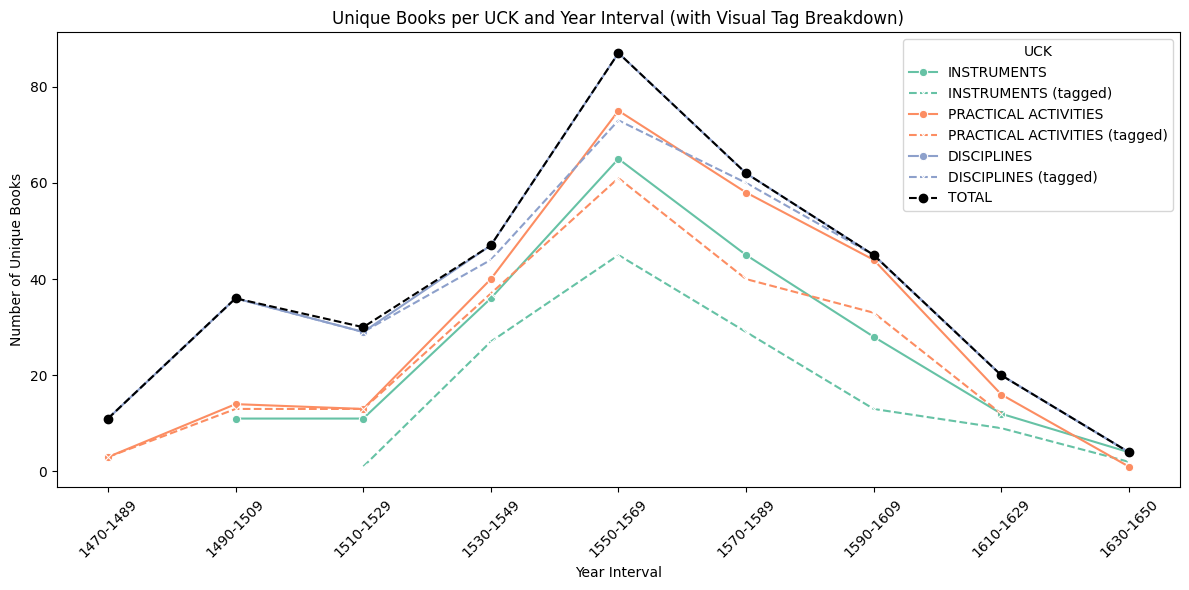

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define UCKs of interest
target_ucks = ['INSTRUMENTS', 'PRACTICAL ACTIVITIES', 'DISCIPLINES']

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()

# ---- Filter for the selected UCKs ----
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# ---- Count unique books per UCK and year_interval (all books) ----
uck_counts_all = (
    filtered.groupby(['uck', 'year_interval'])['book']
    .nunique()
    .reset_index()
    .rename(columns={'book': 'num_unique_books'})
)
uck_counts_all['tagged'] = False

# ---- Count unique books with visual_tag == 'yes' per UCK and year_interval ----
uck_counts_tagged = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby(['uck', 'year_interval'])['book']
    .nunique()
    .reset_index()
    .rename(columns={'book': 'num_unique_books'})
)
uck_counts_tagged['tagged'] = True

# ---- Combine both datasets ----
uck_combined = pd.concat([uck_counts_all, uck_counts_tagged], ignore_index=True)

# ---- Order year_interval ----
year_order = sorted(uck_combined['year_interval'].unique())
uck_combined['year_interval'] = pd.Categorical(uck_combined['year_interval'], categories=year_order, ordered=True)

# ---- Assign consistent colors to each UCK ----
palette = sns.color_palette("Set2", len(target_ucks))
uck_color_map = dict(zip(target_ucks, palette))

# ---- Plot ----
plt.figure(figsize=(12, 6))

for uck in target_ucks:
    color = uck_color_map[uck]
    
    # Solid line: all books
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == False)],
        x='year_interval',
        y='num_unique_books',
        label=uck,
        color=color,
        marker='o'
    )
    
    # Dashed line: tagged books
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == True)],
        x='year_interval',
        y='num_unique_books',
        label=f"{uck} (tagged)",
        color=color,
        linestyle='--',
        marker='x'
    )

# ---- Add TOTAL line (black dashed) ----
total_counts = (
    merged_df.groupby('year_interval')['book']
    .nunique()
    .reset_index()
    .rename(columns={'book': 'num_unique_books'})
)
total_counts['year_interval'] = pd.Categorical(total_counts['year_interval'], categories=year_order, ordered=True)

plt.plot(
    total_counts['year_interval'],
    total_counts['num_unique_books'],
    label='TOTAL',
    color='black',
    linestyle='--',
    marker='o'
)

# ---- Final touches ----
plt.title('Unique Books per UCK and Year Interval (with Visual Tag Breakdown)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='UCK')
plt.tight_layout()

# ---- Save and Show ----
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_uck_lines.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_84140/1803676294.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


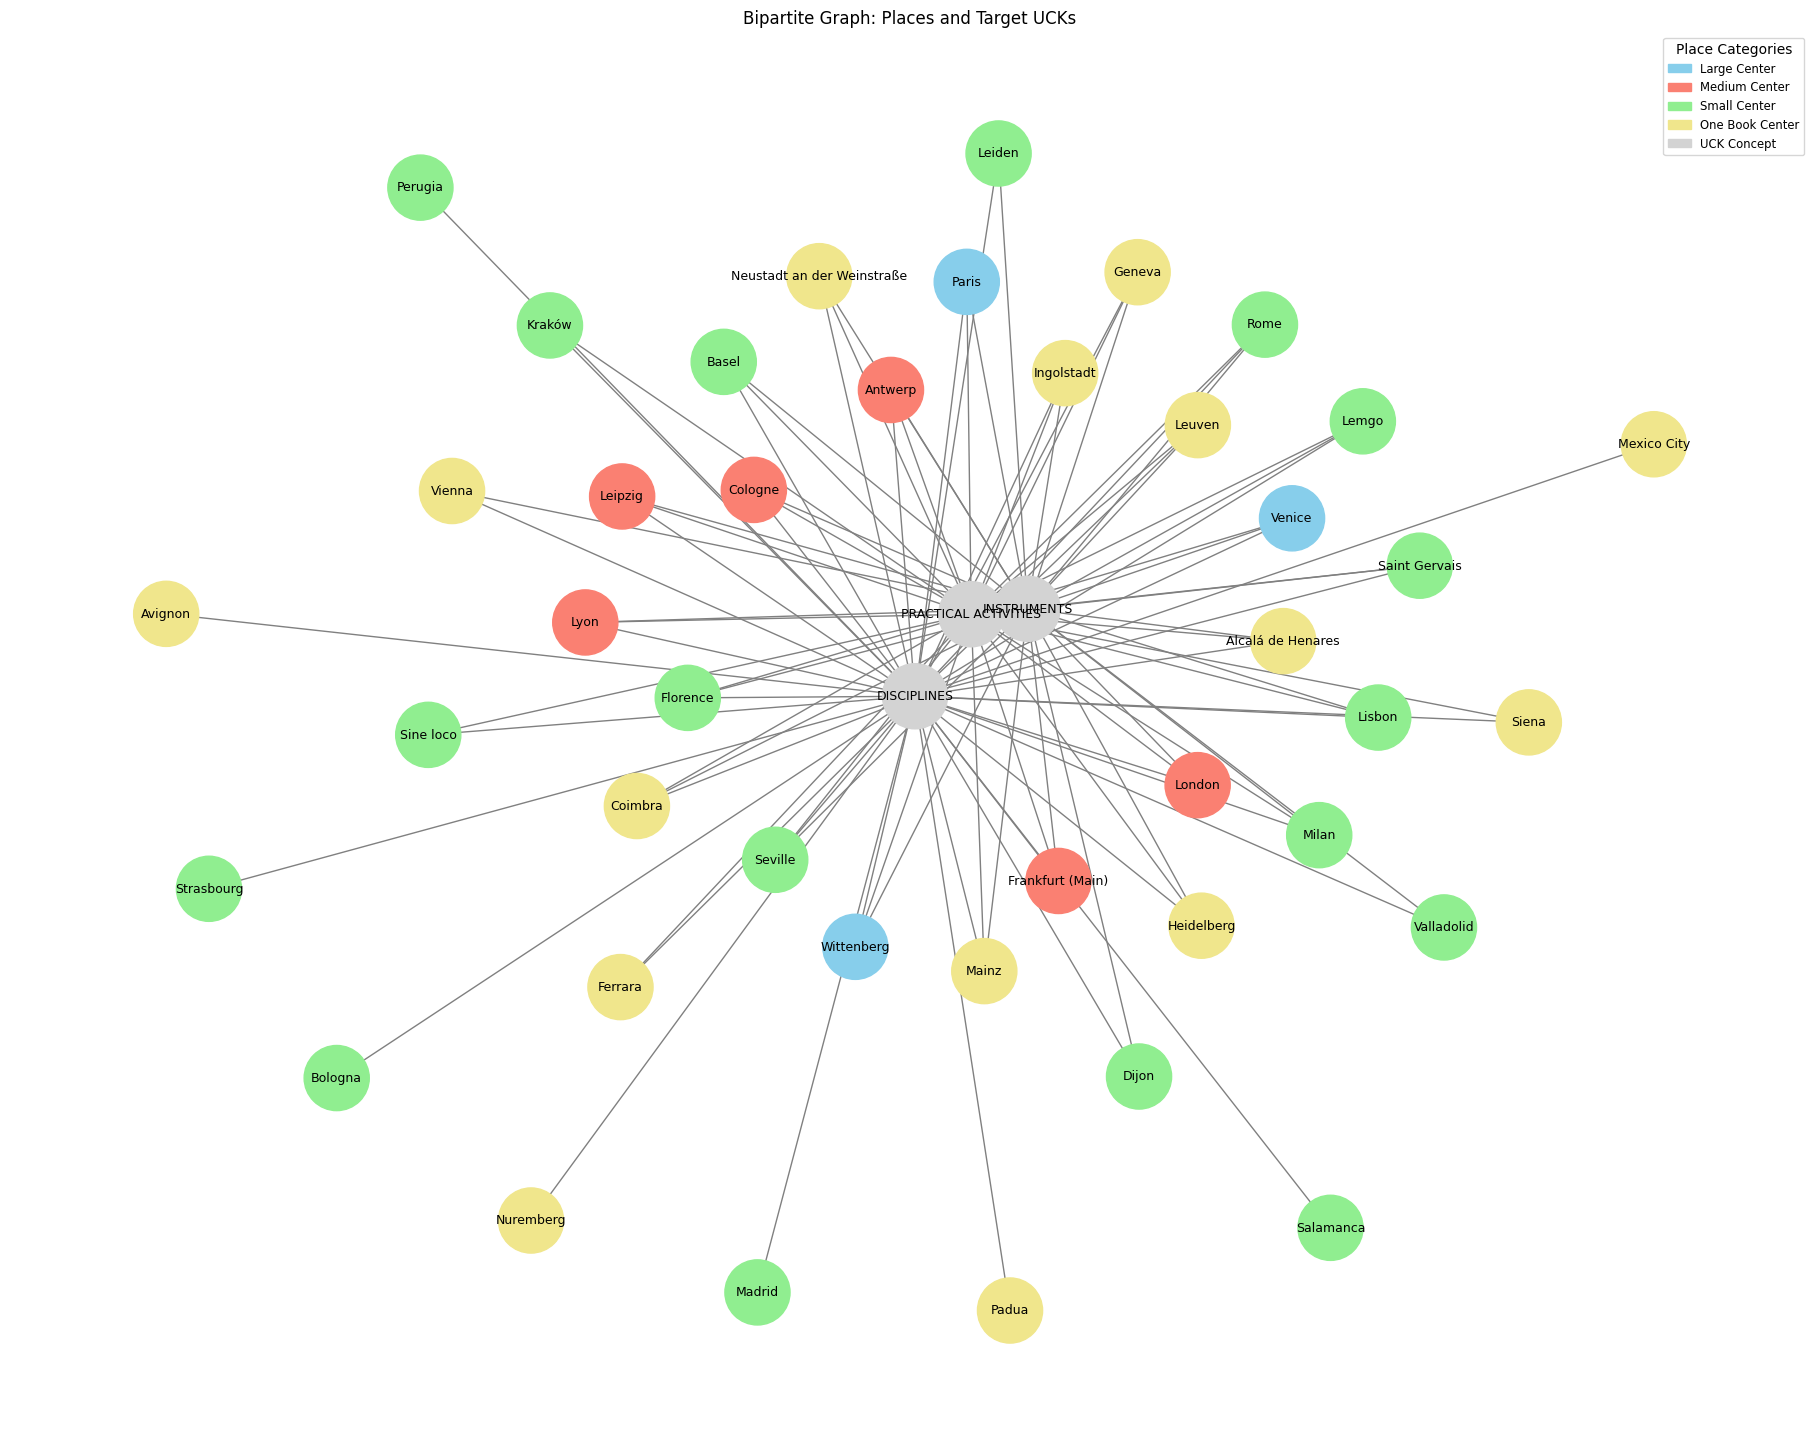

In [113]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

# === Replace this with your actual merged_df ===
# merged_df = pd.read_csv("your_merged_data.csv")

# === Step 1: Define target UCK values ===
target_uck_values = [
   'DISCIPLINES',
    'PRACTICAL ACTIVITIES',
    'INSTRUMENTS'
]

# === Step 2: Filter data ===
filtered_df = merged_df[
    merged_df['uck'].isin(target_uck_values) &
    merged_df['place'].notna()
]

# === Step 3: Create edges (place ↔ uck) ===
edges = list(zip(filtered_df['place'], filtered_df['uck']))
places = filtered_df['place'].unique().tolist()
ucks = filtered_df['uck'].unique().tolist()

# === Step 4: Map place categories to colors ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
existing_categories = filtered_df['place_category'].dropna().unique().tolist()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in places:
    cat_series = filtered_df[filtered_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Step 5: Build and draw the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(ucks, bipartite=1)
G.add_edges_from(edges)

node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, seed=42, k=0.45)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2200,
    font_size=9
)

# === Step 6: Add legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='UCK Concept'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and Target UCKs")
plt.tight_layout()
plt.show()


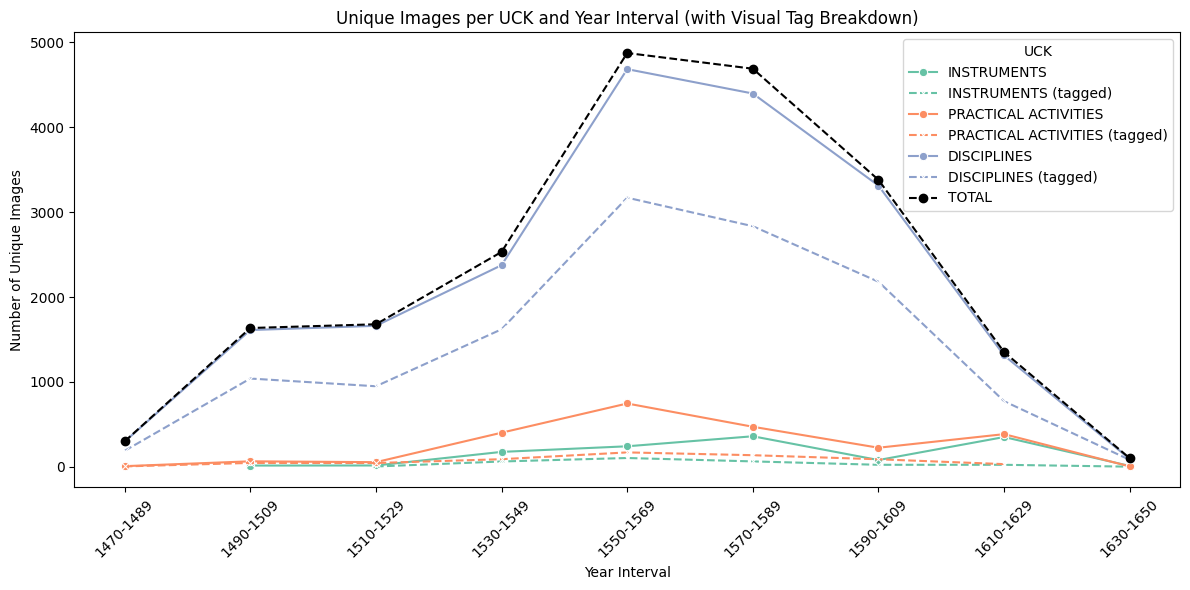

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define UCKs of interest
target_ucks = ['INSTRUMENTS', 'PRACTICAL ACTIVITIES', 'DISCIPLINES']

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()

# ---- Filter for the selected UCKs ----
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# ---- Count unique images per UCK and year_interval (all images) ----
uck_counts_all = (
    filtered.groupby(['uck', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_all['tagged'] = False

# ---- Count unique images with visual_tag == 'yes' per UCK and year_interval ----
uck_counts_tagged = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby(['uck', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_tagged['tagged'] = True

# ---- Combine both datasets ----
uck_combined = pd.concat([uck_counts_all, uck_counts_tagged], ignore_index=True)

# ---- Order year_interval ----
year_order = sorted(uck_combined['year_interval'].unique())
uck_combined['year_interval'] = pd.Categorical(uck_combined['year_interval'], categories=year_order, ordered=True)

# ---- Assign consistent colors to each UCK ----
palette = sns.color_palette("Set2", len(target_ucks))
uck_color_map = dict(zip(target_ucks, palette))

# ---- Plot ----
plt.figure(figsize=(12, 6))

for uck in target_ucks:
    color = uck_color_map[uck]
    
    # Solid line: all images
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == False)],
        x='year_interval',
        y='num_unique_images',
        label=uck,
        color=color,
        marker='o'
    )
    
    # Dashed line: tagged images
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == True)],
        x='year_interval',
        y='num_unique_images',
        label=f"{uck} (tagged)",
        color=color,
        linestyle='--',
        marker='x'
    )

# ---- Add TOTAL line (black dashed) ----
total_counts = (
    merged_df.groupby('year_interval')['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
total_counts['year_interval'] = pd.Categorical(total_counts['year_interval'], categories=year_order, ordered=True)

plt.plot(
    total_counts['year_interval'],
    total_counts['num_unique_images'],
    label='TOTAL',
    color='black',
    linestyle='--',
    marker='o'
)

# ---- Final touches ----
plt.title('Unique Images per UCK and Year Interval (with Visual Tag Breakdown)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=45)
plt.legend(title='UCK')
plt.tight_layout()

# ---- Save and Show ----
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_uck_lines.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_84140/953940124.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


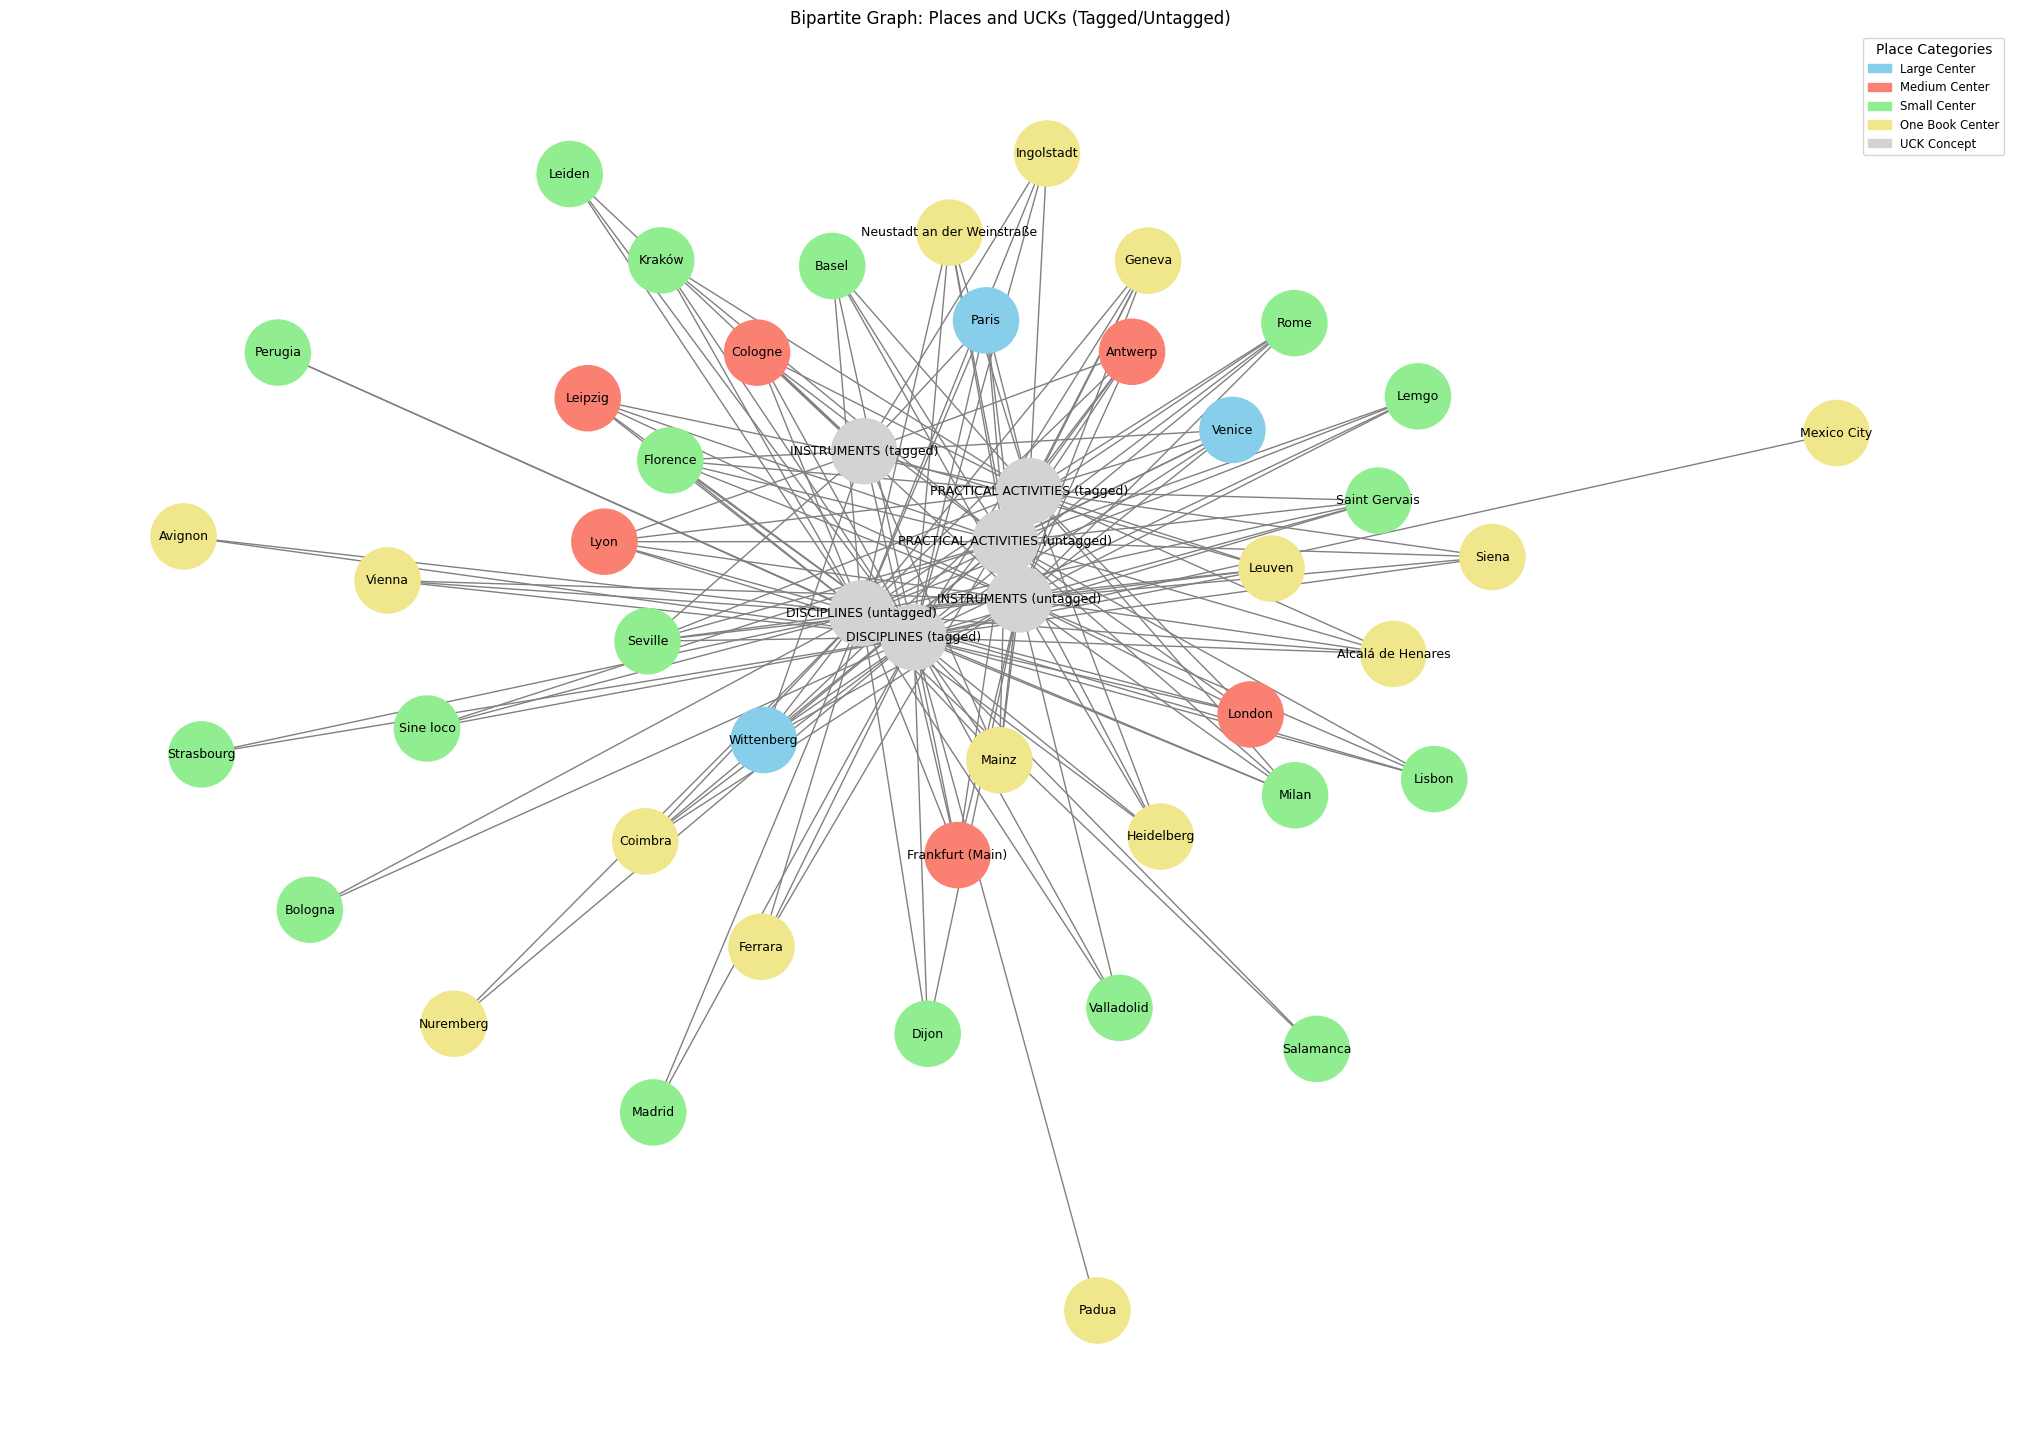

In [126]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

# === Define target UCKs ===
target_uck_values = ['DISCIPLINES', 'PRACTICAL ACTIVITIES', 'INSTRUMENTS']

# === Ensure string types and clean data ===
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()
merged_df['place'] = merged_df['place'].astype(str).str.strip()
merged_df['place_category'] = merged_df['place_category'].astype(str).str.strip()

# === Create new UCK labels with visual_tag ===
merged_df['uck_tagged'] = merged_df.apply(
    lambda row: f"{row['uck']} (tagged)" if row['visual_tag'].lower() == 'yes' else f"{row['uck']} (untagged)",
    axis=1
)

# === Filter for target UCKs only ===
filtered_df = merged_df[merged_df['uck'].isin(target_uck_values)].copy()

# === Get unique places from the full dataframe ===
all_places = merged_df['place'].unique().tolist()

# === Create edges (place ↔ tagged_uck) ===
edges = list(zip(filtered_df['place'], filtered_df['uck_tagged']))

# === Map place categories to colors ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
existing_categories = merged_df['place_category'].dropna().unique().tolist()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in all_places:
    cat_series = merged_df[merged_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Build Graph ===
G = nx.Graph()
G.add_nodes_from(all_places, bipartite=0)

# Add tagged/untagged UCK nodes
uck_nodes = filtered_df['uck_tagged'].unique().tolist()
G.add_nodes_from(uck_nodes, bipartite=1)

# Add edges
G.add_edges_from(edges)

# === Assign node colors ===
node_colors = [
    place_color_map[node] if node in all_places else 'lightgray'
    for node in G.nodes()
]

# === Draw Graph ===
plt.figure(figsize=(20, 14))
pos = nx.spring_layout(G, seed=42, k=0.45)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2200,
    font_size=9
)

# === Add Legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='UCK Concept'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and UCKs (Tagged/Untagged)")
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5.1_uck_place_network.png', dpi=300)


plt.show()


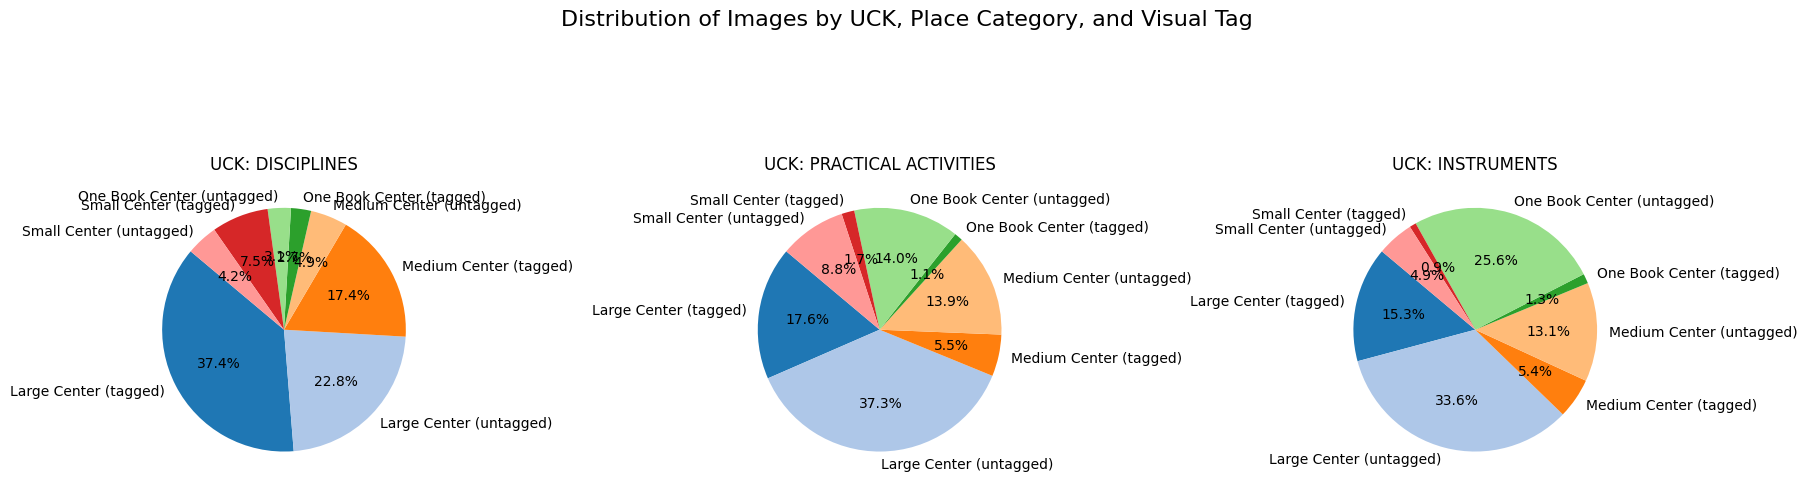

In [127]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure columns are clean ---
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()
merged_df['place_category'] = merged_df['place_category'].astype(str).str.strip()

# --- Define UCKs of interest ---
target_uck_values = ['DISCIPLINES', 'PRACTICAL ACTIVITIES', 'INSTRUMENTS']

# --- Prepare subplot layout ---
num_ucks = len(target_uck_values)
fig, axes = plt.subplots(1, num_ucks, figsize=(6 * num_ucks, 6))  # One row, multiple columns

# --- Use tab20 colormap (enough distinct colors) ---
colors = plt.cm.tab20.colors

for i, uck in enumerate(target_uck_values):
    ax = axes[i]  # Get subplot axis

    # Filter for current UCK
    subset_df = merged_df[merged_df['uck'] == uck].copy()

    # Skip if no data
    if subset_df.empty:
        print(f"⚠️ No data found for UCK: {uck}")
        ax.axis('off')
        continue

    # Create group label: e.g. 'Large Center (tagged)' or 'Small Center (untagged)'
    subset_df['group_label'] = subset_df.apply(
        lambda row: f"{row['place_category']} (tagged)" if row['visual_tag'].lower() == 'yes' else f"{row['place_category']} (untagged)",
        axis=1
    )

    # Group and count unique images
    grouped = (
        subset_df.groupby('group_label')['images']
        .nunique()
        .reset_index()
        .rename(columns={'images': 'num_images'})
    )

    # Remove 0-counts
    grouped = grouped[grouped['num_images'] > 0]

    # Skip if no valid data
    if grouped.empty:
        print(f"⚠️ No image data to plot for UCK: {uck}")
        ax.axis('off')
        continue

    # Plot pie chart on its axis
    ax.pie(
        grouped['num_images'],
        labels=grouped['group_label'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors
    )
    ax.set_title(f'UCK: {uck}', fontsize=12)

# Final layout adjustment
plt.suptitle("Distribution of Images by UCK, Place Category, and Visual Tag", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5.1_uck_place_cat_pies.png', dpi=300)


plt.show()


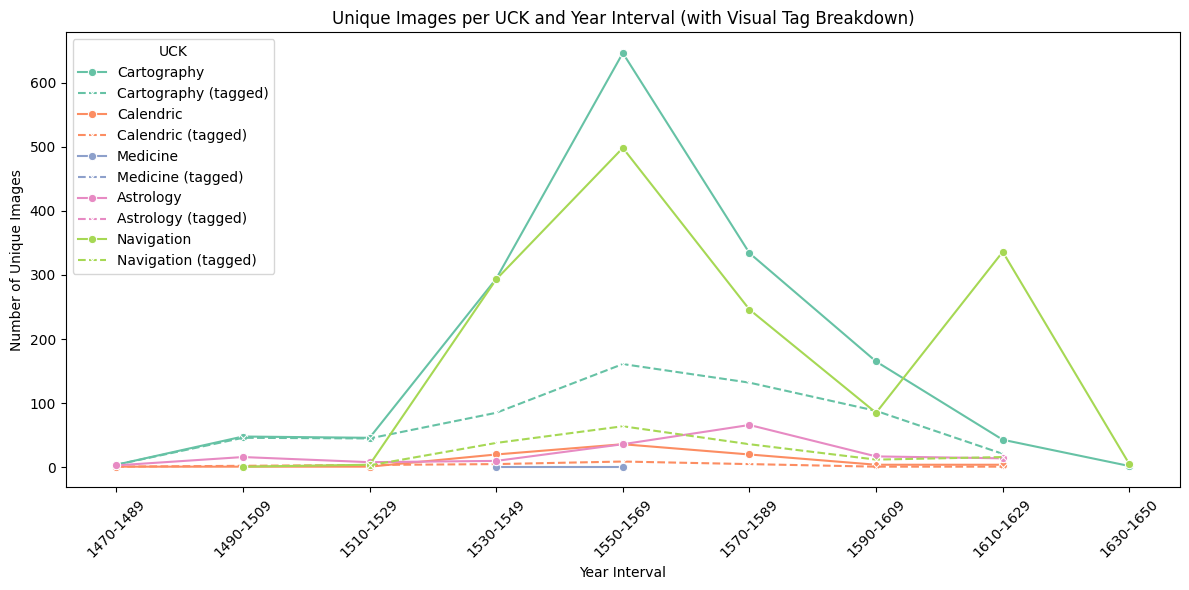

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define UCKs of interest
target_ucks = [
    'Cartography', 
    'Calendric', 
    'Medicine',
    'Astrology',
    'Navigation'
]

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()

# ---- Filter for the selected UCKs ----
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# ---- Count unique images per UCK and year_interval (all images) ----
uck_counts_all = (
    filtered.groupby(['uck', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_all['tagged'] = False

# ---- Count unique images with visual_tag == 'yes' per UCK and year_interval ----
uck_counts_tagged = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby(['uck', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_tagged['tagged'] = True

# ---- Combine both datasets ----
uck_combined = pd.concat([uck_counts_all, uck_counts_tagged], ignore_index=True)

# ---- Order year_interval ----
year_order = sorted(uck_combined['year_interval'].unique())
uck_combined['year_interval'] = pd.Categorical(uck_combined['year_interval'], categories=year_order, ordered=True)

# ---- Assign consistent colors to each UCK ----
palette = sns.color_palette("Set2", len(target_ucks))
uck_color_map = dict(zip(target_ucks, palette))

# ---- Plot ----
plt.figure(figsize=(12, 6))

for uck in target_ucks:
    color = uck_color_map[uck]
    
    # Solid line: all images
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == False)],
        x='year_interval',
        y='num_unique_images',
        label=uck,
        color=color,
        marker='o'
    )
    
    # Dashed line: tagged images
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == True)],
        x='year_interval',
        y='num_unique_images',
        label=f"{uck} (tagged)",
        color=color,
        linestyle='--',
        marker='x'
    )

# # ---- Add TOTAL line (black dashed) ----
# total_counts = (
#     merged_df.groupby('year_interval')['images']
#     .nunique()
#     .reset_index()
#     .rename(columns={'images': 'num_unique_images'})
# )
# total_counts['year_interval'] = pd.Categorical(total_counts['year_interval'], categories=year_order, ordered=True)

# plt.plot(
#     total_counts['year_interval'],
#     total_counts['num_unique_images'],
#     label='TOTAL',
#     color='black',
#     linestyle='--',
#     marker='o'
# )

# ---- Final touches ----
plt.title('Unique Images per UCK and Year Interval (with Visual Tag Breakdown)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=45)
plt.legend(title='UCK')
plt.tight_layout()

# ---- Save and Show ----
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5.2_practical_activites_lines.png', dpi=300)
plt.show()


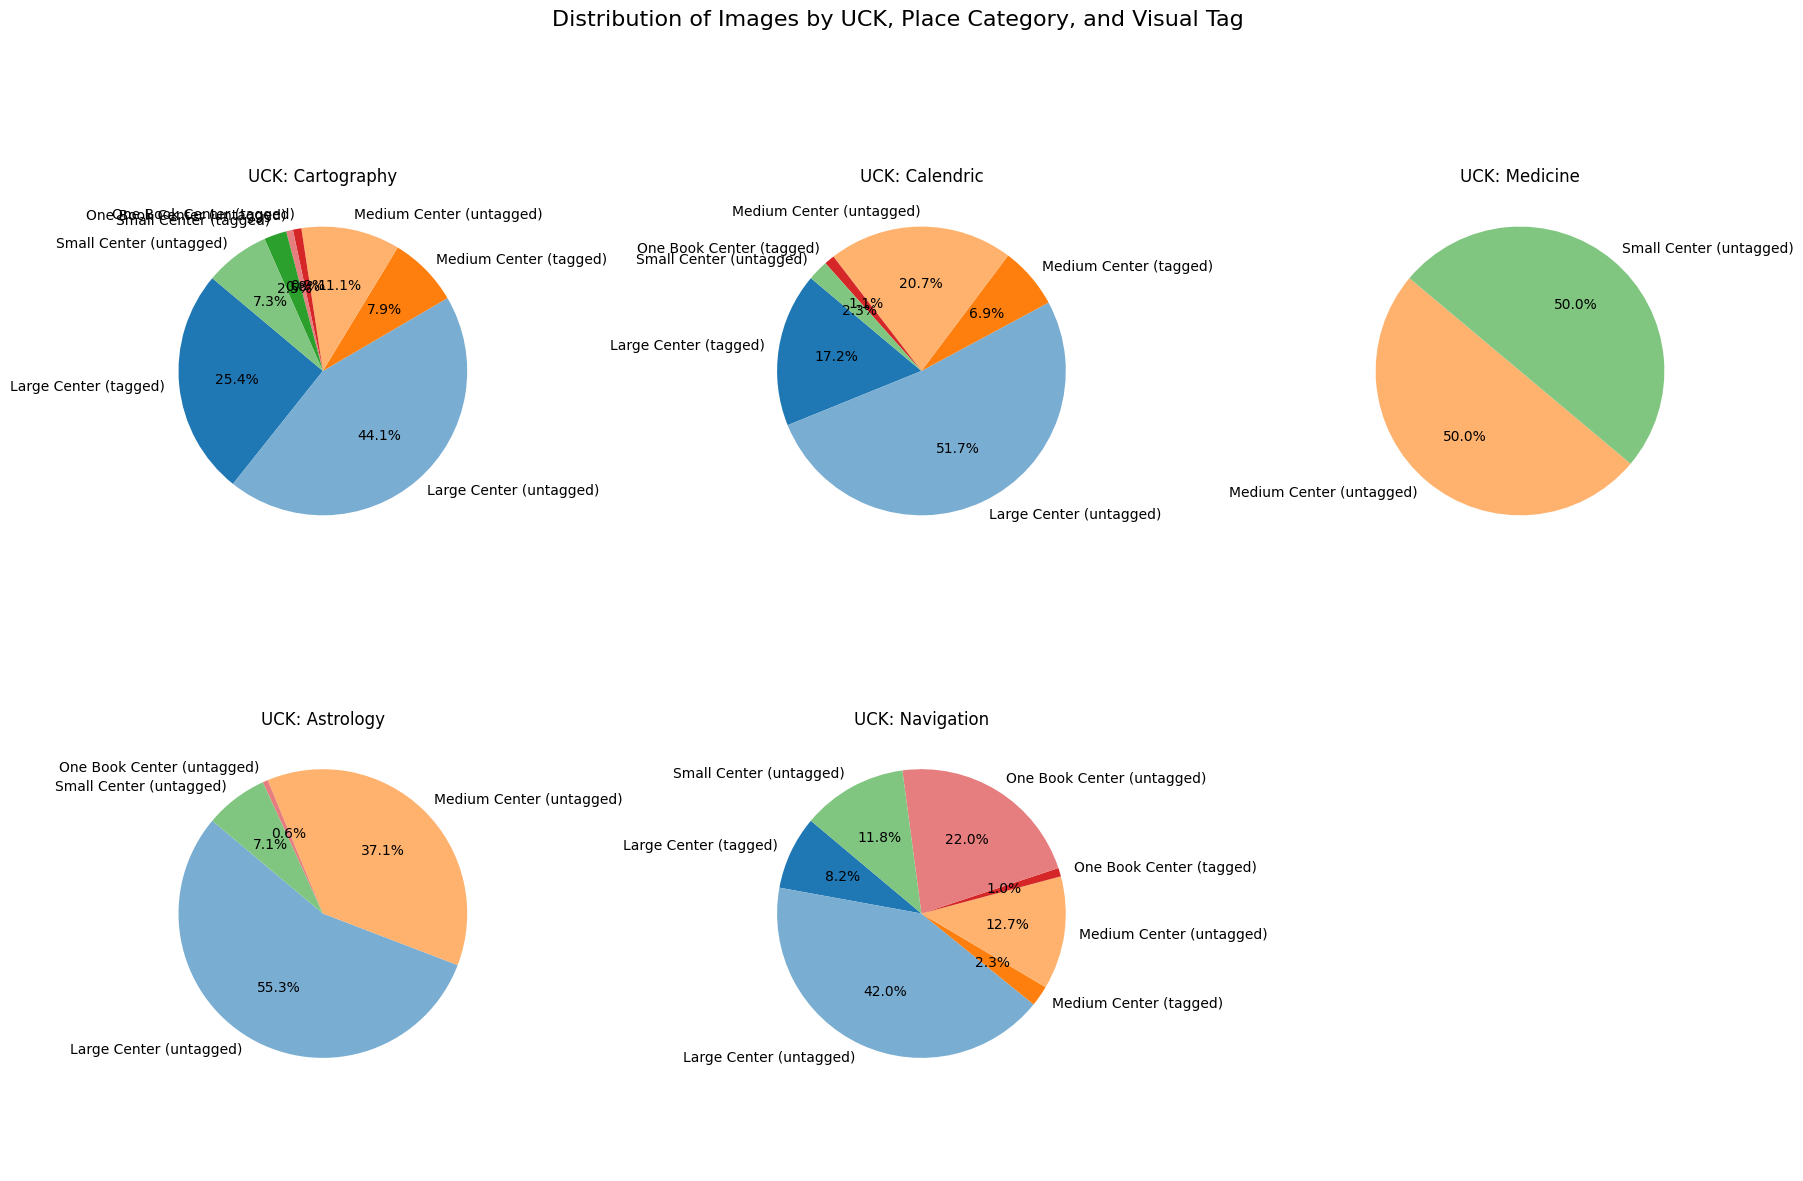

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Ensure columns are clean ---
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()
merged_df['place_category'] = merged_df['place_category'].astype(str).str.strip()

# --- Define UCKs of interest ---
target_uck_values = [
    'Cartography', 
    'Calendric', 
    'Medicine',
    'Astrology',
    'Navigation'    
]

# --- Define consistent base colors for each place category ---
base_colors = {
    'Large Center': '#1f77b4',     # blue
    'Medium Center': '#ff7f0e',    # orange
    'Small Center': '#2ca02c',     # green
    'One Book Center': '#d62728'   # red
}

# Generate lighter (desaturated) version for untagged
def desaturate(color_hex, amount=0.4):
    rgb = mcolors.to_rgb(color_hex)
    return mcolors.to_hex([(1 - amount) * c + amount for c in rgb])

# Create full color map for pie slices
pie_color_map = {}
for cat, base in base_colors.items():
    pie_color_map[f'{cat} (tagged)'] = base
    pie_color_map[f'{cat} (untagged)'] = desaturate(base)

# --- Prepare subplot layout: 2 rows, 3 columns (to fit 5 plots) ---
n_rows = 2
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

# Flatten axes for easy indexing
axes = axes.flatten()

for i, uck in enumerate(target_uck_values):
    ax = axes[i]

    # Filter for current UCK
    subset_df = merged_df[merged_df['uck'] == uck].copy()

    # Skip if no data
    if subset_df.empty:
        print(f"⚠️ No data found for UCK: {uck}")
        ax.axis('off')
        continue

    # Create group label: e.g. 'Large Center (tagged)' or 'Small Center (untagged)'
    subset_df['group_label'] = subset_df.apply(
        lambda row: f"{row['place_category']} (tagged)" if row['visual_tag'].lower() == 'yes' else f"{row['place_category']} (untagged)",
        axis=1
    )

    # Group and count unique images
    grouped = (
        subset_df.groupby('group_label')['images']
        .nunique()
        .reset_index()
        .rename(columns={'images': 'num_images'})
    )

    # Remove 0-counts
    grouped = grouped[grouped['num_images'] > 0]

    # Skip if no valid data
    if grouped.empty:
        print(f"⚠️ No image data to plot for UCK: {uck}")
        ax.axis('off')
        continue

    # Map colors for pie slices
    slice_colors = [pie_color_map.get(label, 'gray') for label in grouped['group_label']]

    # Plot pie chart
    ax.pie(
        grouped['num_images'],
        labels=grouped['group_label'],
        autopct='%1.1f%%',
        startangle=140,
        colors=slice_colors
    )
    ax.set_title(f'UCK: {uck}', fontsize=12)

# Turn off any unused subplots (e.g. last one if only 5 UCKs)
for j in range(len(target_uck_values), len(axes)):
    axes[j].axis('off')

# Final layout adjustment
plt.suptitle("Distribution of Images by UCK, Place Category, and Visual Tag", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save and show
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5.2_practical_activities_cat_pies.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_84140/3166204246.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


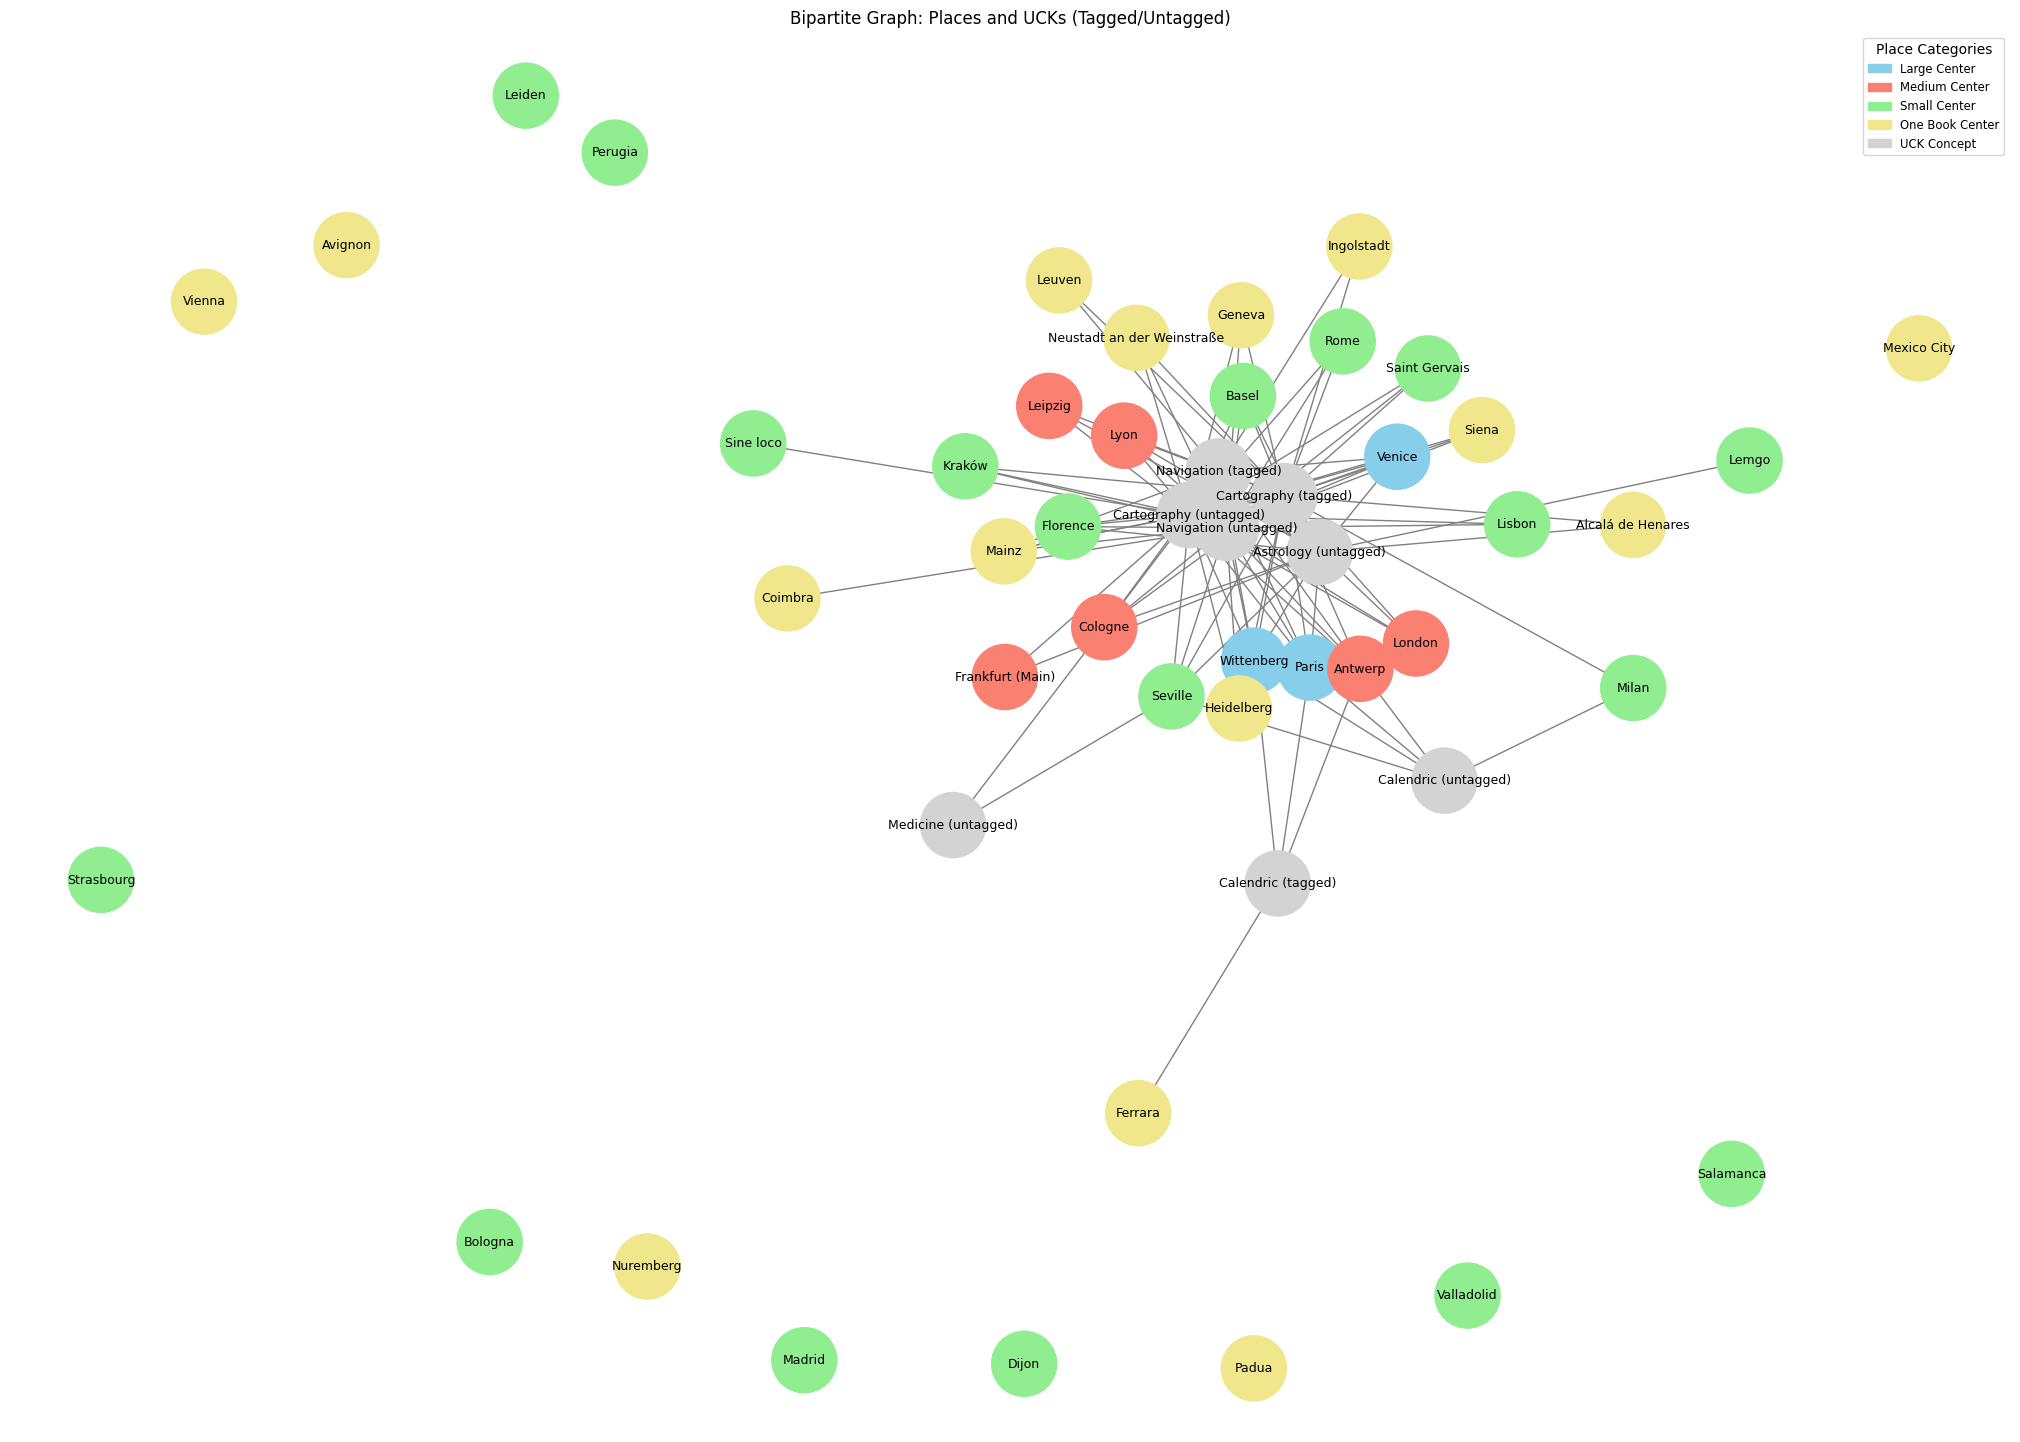

In [134]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

# === Define target UCKs ===

target_uck_values = [
  'Cartography', 
    'Calendric', 
    'Medicine',
    'Astrology',
    'Navigation'    
]



# === Ensure string types and clean data ===
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()
merged_df['place'] = merged_df['place'].astype(str).str.strip()
merged_df['place_category'] = merged_df['place_category'].astype(str).str.strip()

# === Create new UCK labels with visual_tag ===
merged_df['uck_tagged'] = merged_df.apply(
    lambda row: f"{row['uck']} (tagged)" if row['visual_tag'].lower() == 'yes' else f"{row['uck']} (untagged)",
    axis=1
)

# === Filter for target UCKs only ===
filtered_df = merged_df[merged_df['uck'].isin(target_uck_values)].copy()

# === Get unique places from the full dataframe ===
all_places = merged_df['place'].unique().tolist()

# === Create edges (place ↔ tagged_uck) ===
edges = list(zip(filtered_df['place'], filtered_df['uck_tagged']))

# === Map place categories to colors ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
existing_categories = merged_df['place_category'].dropna().unique().tolist()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in all_places:
    cat_series = merged_df[merged_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Build Graph ===
G = nx.Graph()
G.add_nodes_from(all_places, bipartite=0)

# Add tagged/untagged UCK nodes
uck_nodes = filtered_df['uck_tagged'].unique().tolist()
G.add_nodes_from(uck_nodes, bipartite=1)

# Add edges
G.add_edges_from(edges)

# === Assign node colors ===
node_colors = [
    place_color_map[node] if node in all_places else 'lightgray'
    for node in G.nodes()
]

# === Draw Graph ===
plt.figure(figsize=(20, 14))
pos = nx.spring_layout(G, seed=42, k=0.45)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2200,
    font_size=9
)

# === Add Legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='UCK Concept'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and UCKs (Tagged/Untagged)")
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5.2_practical_activities_place_network.png', dpi=300)


plt.show()
